In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  # for interactive charts

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('unemployment_data.csv')
print(df.head())


           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [5]:
print(df.shape)


(768, 7)


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 66.1 KB
None


In [8]:
#cleaning the column names by removing leading and trailing spaces
df.columns = df.columns.str.strip()
# Check missing values
print(df.isnull().sum())

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [9]:
# Date column ko datetime format mein convert krna
df['Date'] = pd.to_datetime(df['Date'])

# Duplicates check
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

print(df.describe())

27
                             Date  Estimated Unemployment Rate (%)  \
count                         740                       740.000000   
mean   2019-12-12 18:36:58.378378                        11.787946   
min           2019-05-31 00:00:00                         0.000000   
25%           2019-08-31 00:00:00                         4.657500   
50%           2019-11-30 00:00:00                         8.350000   
75%           2020-03-31 00:00:00                        15.887500   
max           2020-06-30 00:00:00                        76.740000   
std                           NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  
count        7.400000e+02                               740.000000  
mean         7.204460e+06                                42.630122  
min          4.942000e+04                                13.330000  
25%          1.190404e+06                                38.062500  
50%          4.744178

Exploaroty data analysis (EDA)

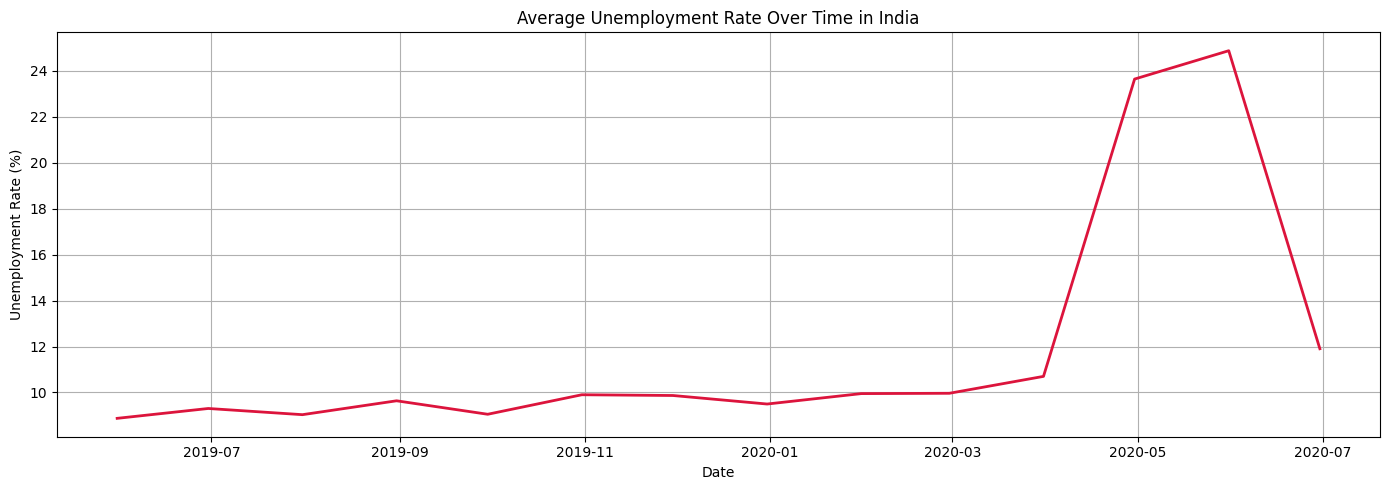

In [11]:
#Overall Unemployment Rate over Time
df_grouped = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(df_grouped['Date'], df_grouped['Estimated Unemployment Rate (%)'], color='crimson', linewidth=2)
plt.title('Average Unemployment Rate Over Time in India')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

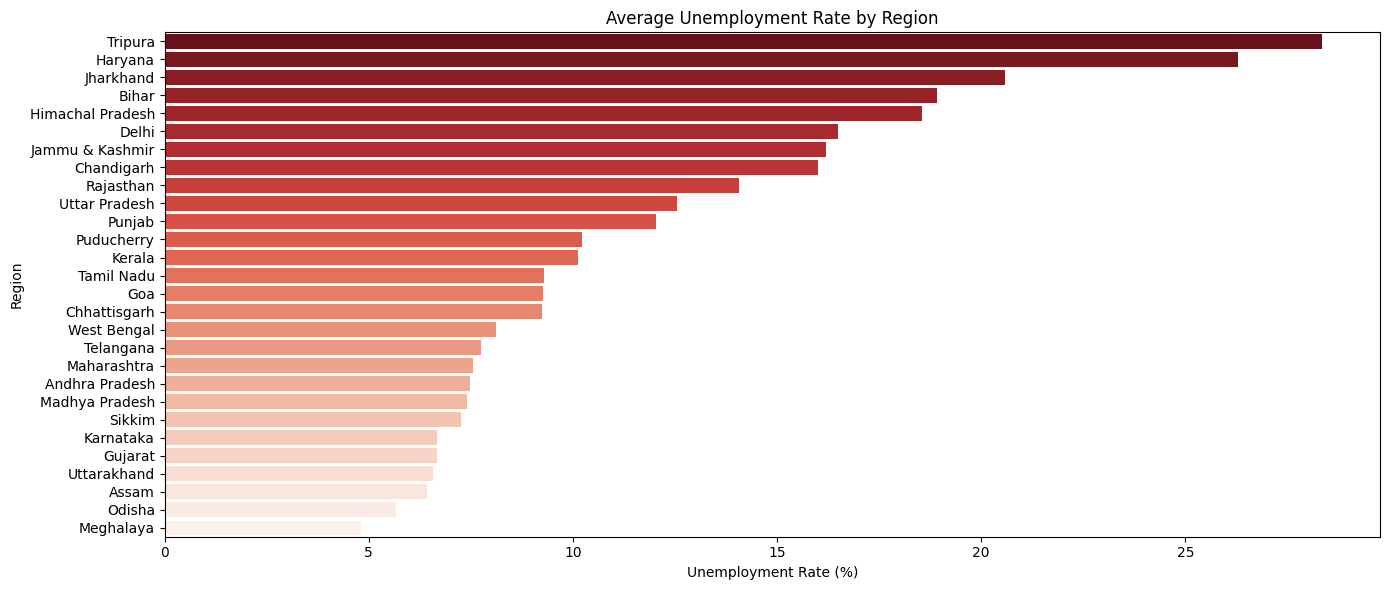

In [13]:
#Region-wise Average Unemployment
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=region_avg.values, y=region_avg.index, palette='Reds_r')
plt.title('Average Unemployment Rate by Region')
plt.xlabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

COVID 19 IMPACT ANALYSIS (MOST IMP PART)

Period
During Covid    17.774363
Pre Covid        9.509534
Name: Estimated Unemployment Rate (%), dtype: float64


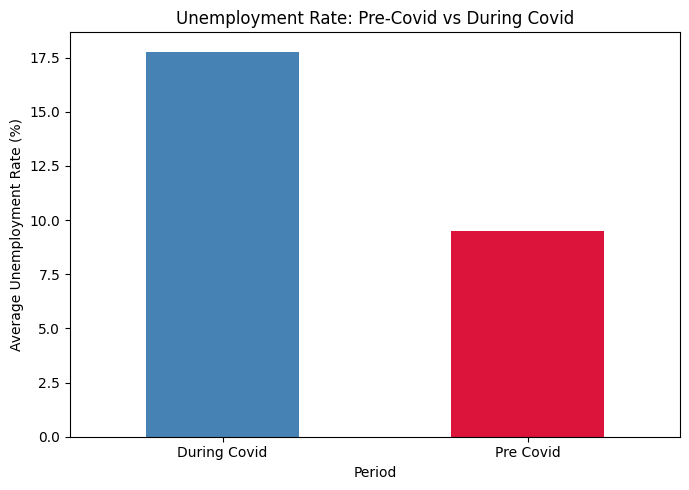

In [16]:
# Pre-Covid vs During-Covid split (lockdown March 2020 se shuru hua)
df['Period'] = df['Date'].apply(lambda x: 'During Covid' if x >= pd.to_datetime('2020-03-01') else 'Pre Covid')

covid_comparison = df.groupby('Period')['Estimated Unemployment Rate (%)'].mean()
print(covid_comparison)

# Bar chart
covid_comparison.plot(kind='bar', color=['steelblue', 'crimson'], figsize=(7, 5))
plt.title('Unemployment Rate: Pre-Covid vs During Covid')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Heatmap — Region × Month

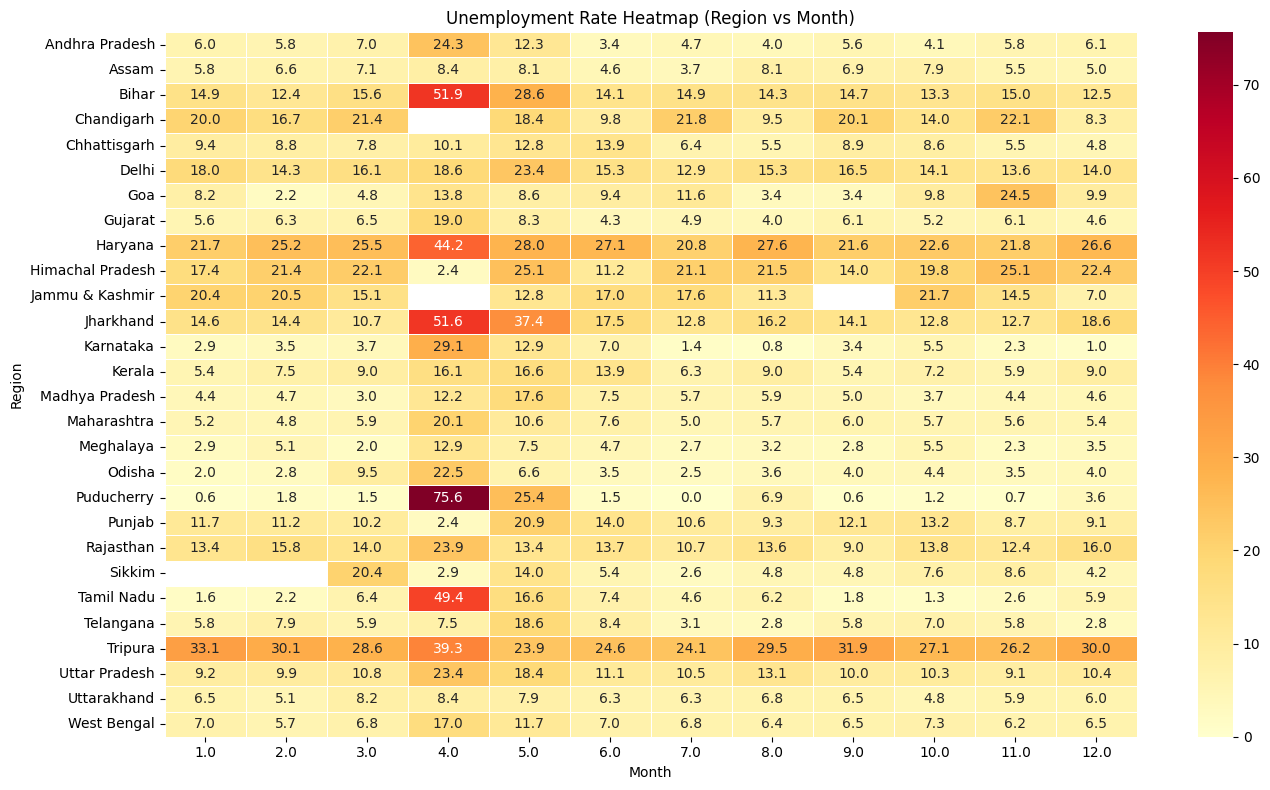

In [17]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

pivot = df.pivot_table(values='Estimated Unemployment Rate (%)', 
                        index='Region', columns='Month', aggfunc='mean')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Unemployment Rate Heatmap (Region vs Month)')
plt.tight_layout()
plt.show()

In [19]:
#INTERACTIVE MAP OF UNEMPLOYMENT RATE ACROSS INDIAN STATES WITH PLOTLY
fig = px.choropleth(
    df,
    geojson="https://gist.githubusercontent.com/jbrobst/56c13bbbf9d97d187fea01ca62ea5112/raw/e388c4cae20aa53cb5090210a42ebb9b765c0a36/india_states.geojson",
    featureidkey='properties.ST_NM',
    locations='Region',
    color='Estimated Unemployment Rate (%)',
    color_continuous_scale='Reds',
    title='Unemployment Rate Across Indian States'
)
fig.update_geos(fitbounds="locations", visible=False)
fig.show()

In [21]:
""" Key Findings:
1. Unemployment rate sharply SPIKED during April-May 2020 (Covid lockdown).
2. States like Haryana, Jharkhand showed highest unemployment.
3. Southern states generally had lower unemployment rates.
4. Post-lockdown (Jul 2020 onwards) gradual recovery visible.
5. Labour Participation Rate dropped alongside unemployment rise """

' Key Findings:\n1. Unemployment rate sharply SPIKED during April-May 2020 (Covid lockdown).\n2. States like Haryana, Jharkhand showed highest unemployment.\n3. Southern states generally had lower unemployment rates.\n4. Post-lockdown (Jul 2020 onwards) gradual recovery visible.\n5. Labour Participation Rate dropped alongside unemployment rise '